/tmp/ipykernel_449284/2264013843.py:51: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  temperature_df[key] = pd.concat([temperature_df[key], temp])
/tmp/ipykernel_449284/2264013843.py:52: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  humidity_df[key] = pd.concat([humidity_df[key], q])


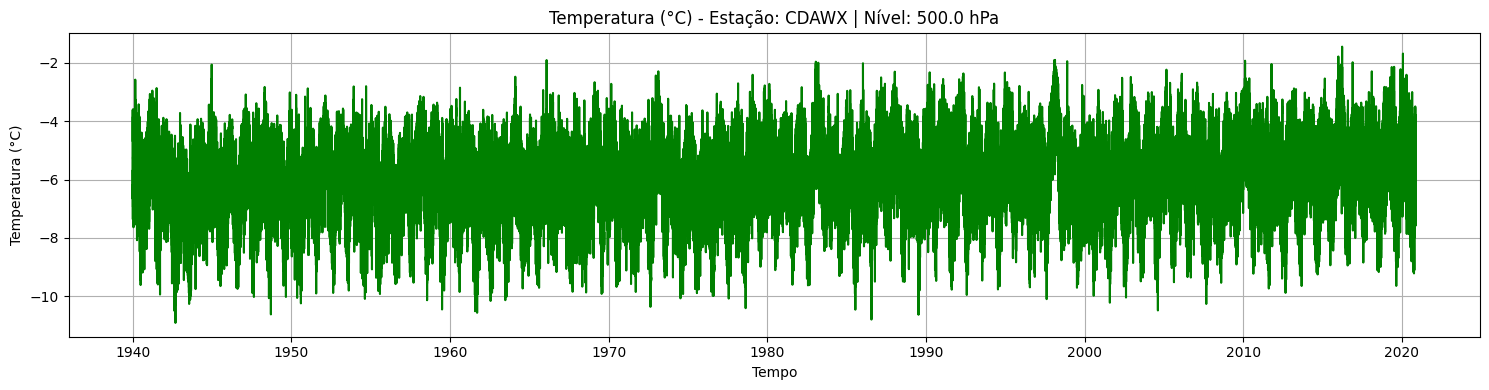

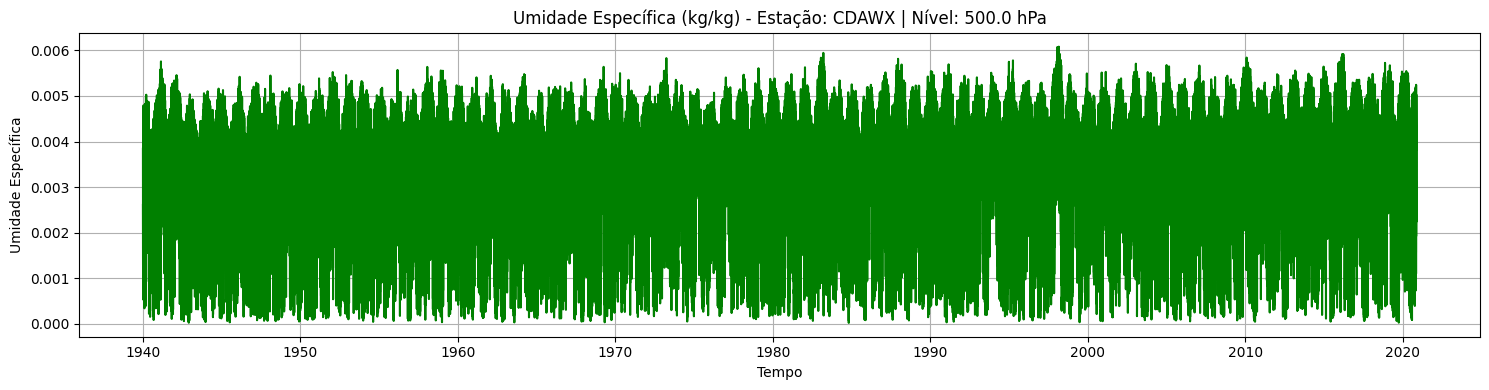

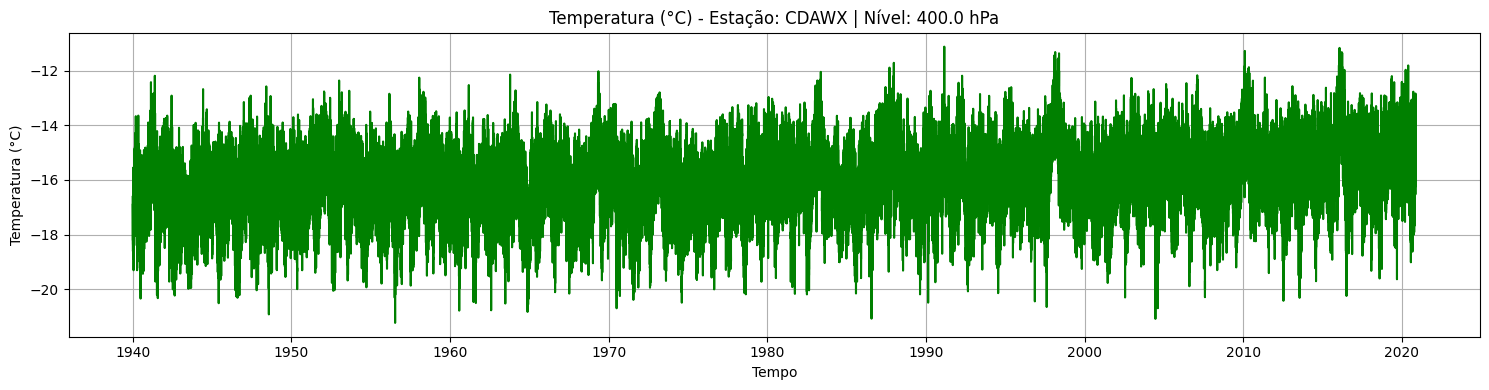

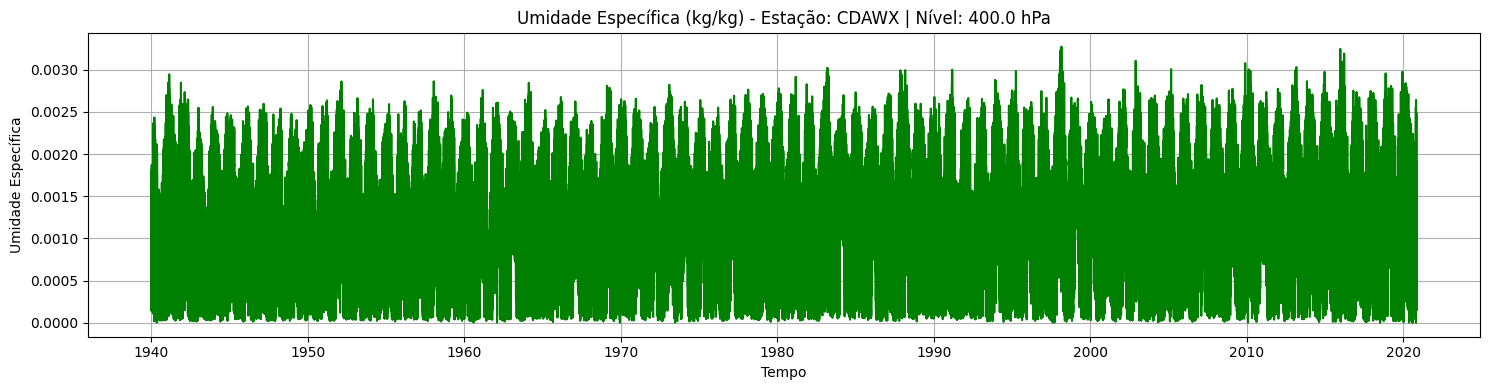

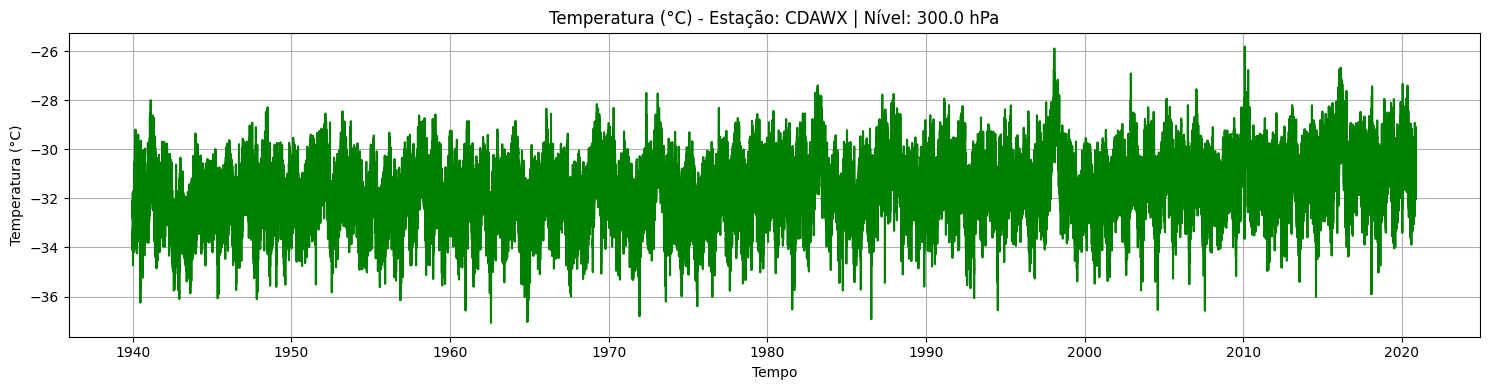

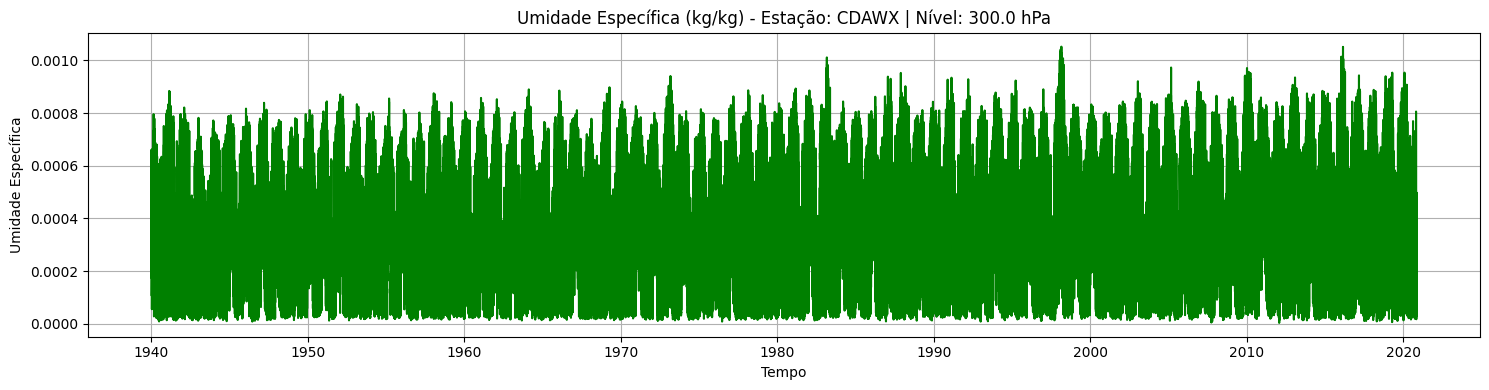

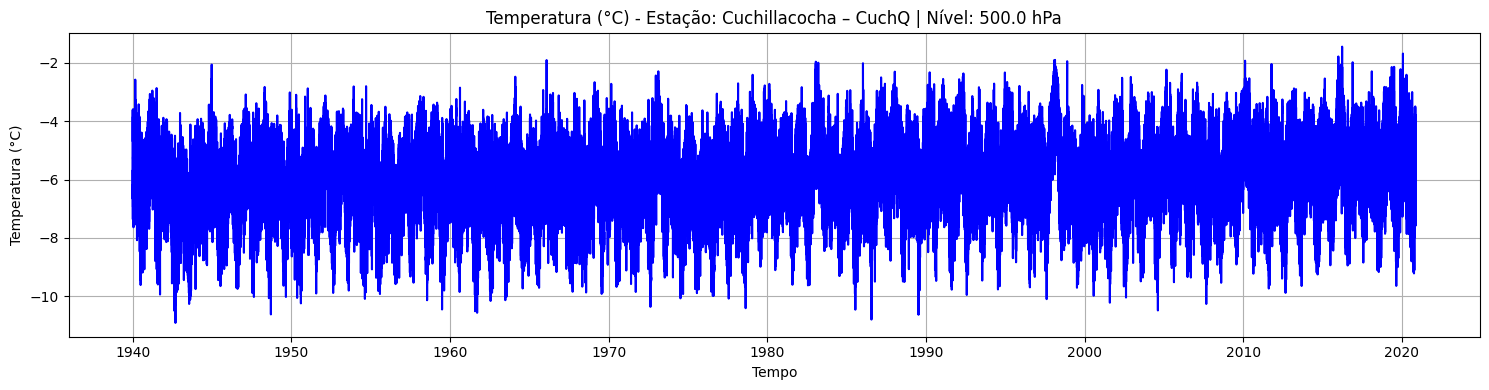

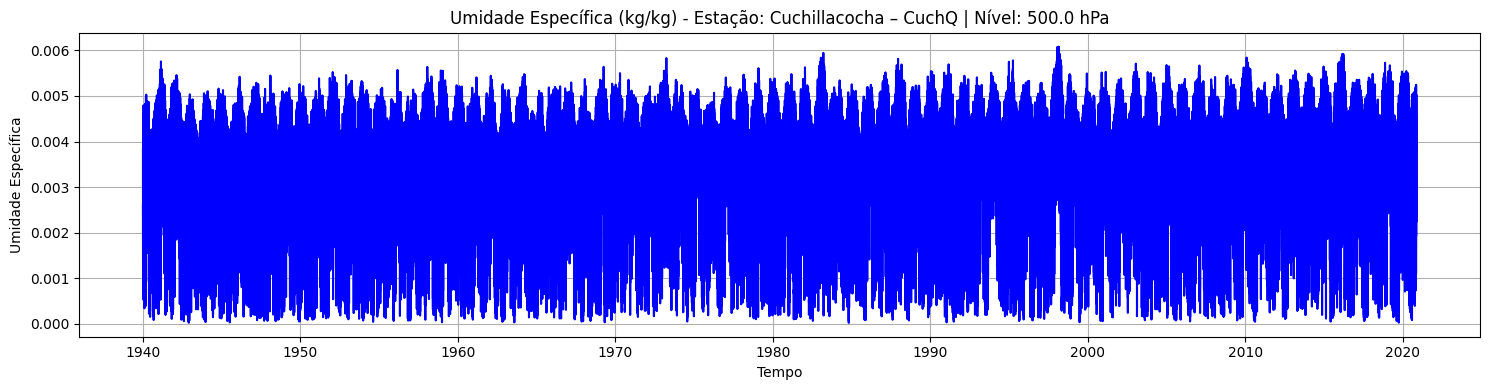

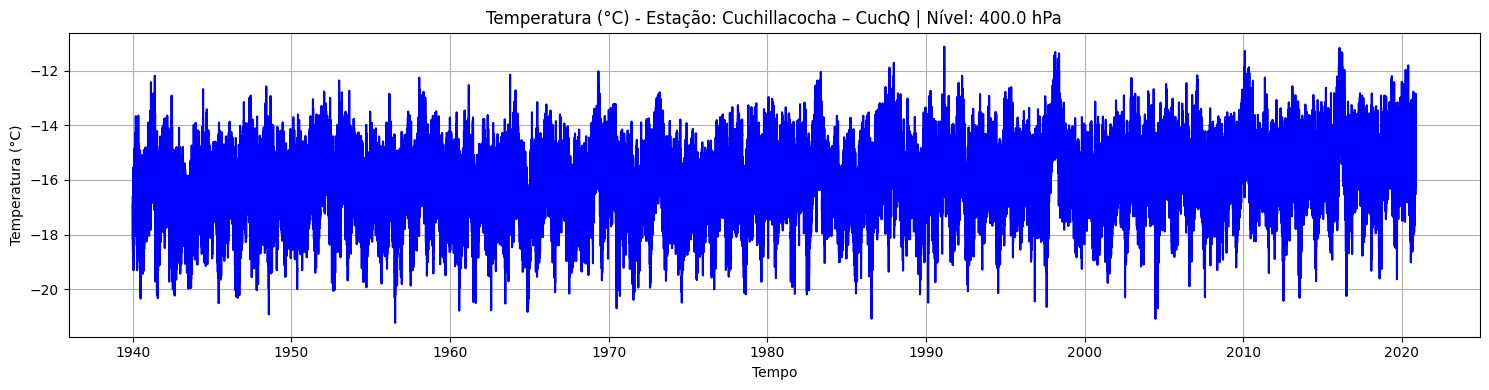

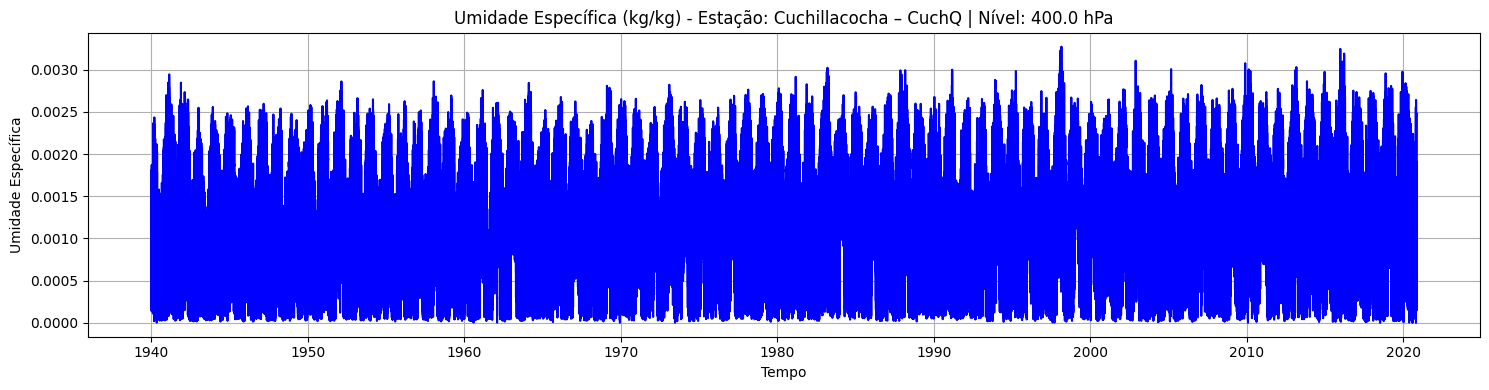

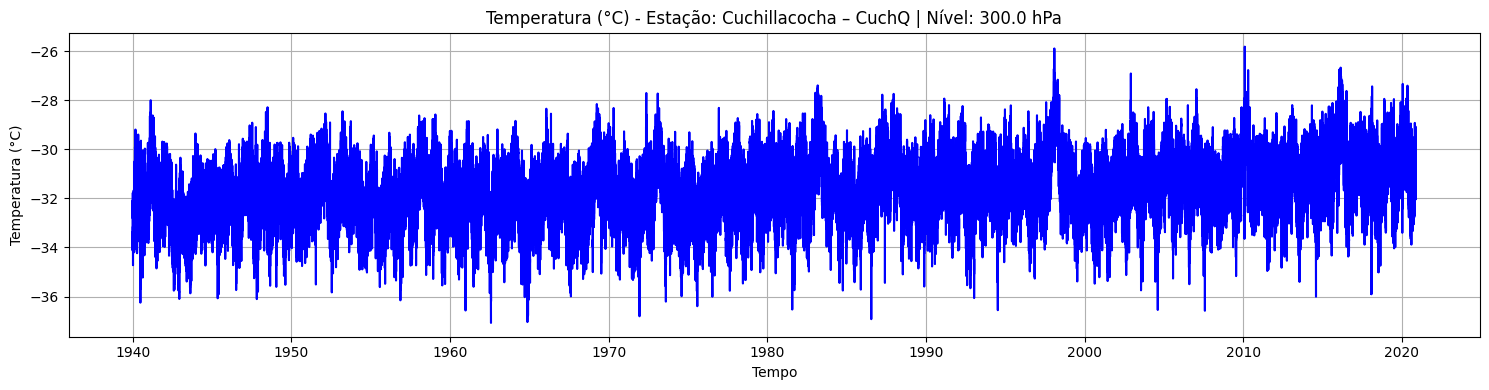

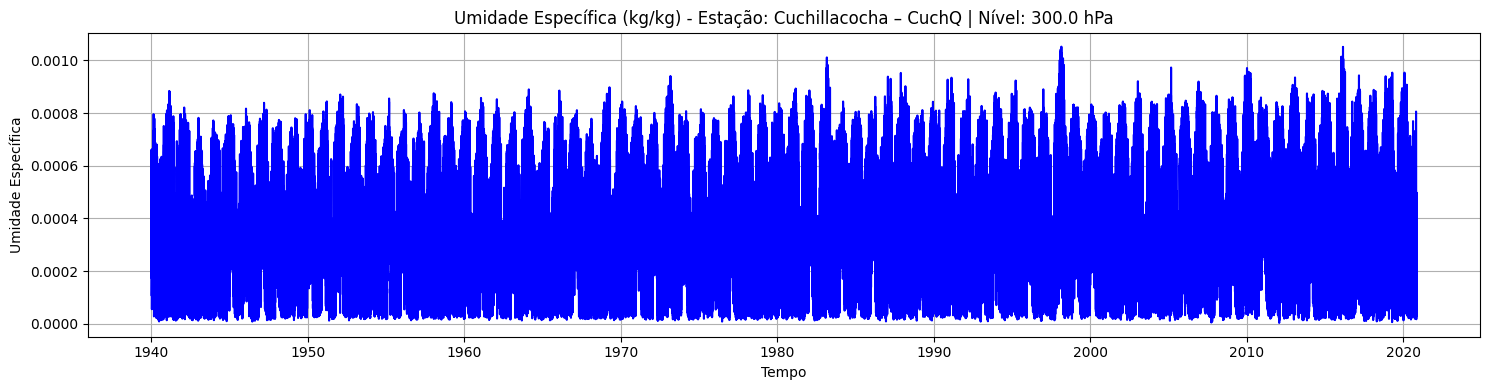

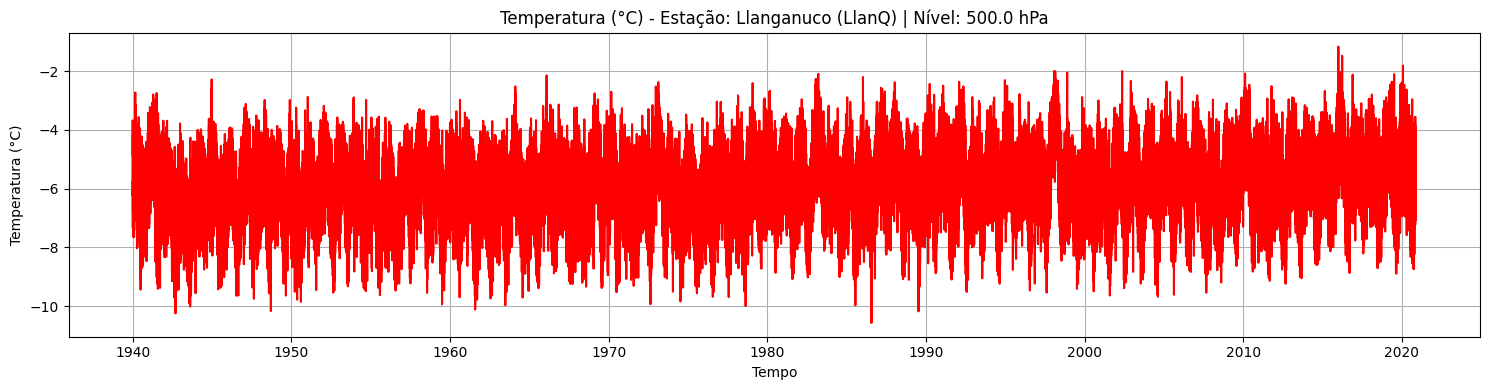

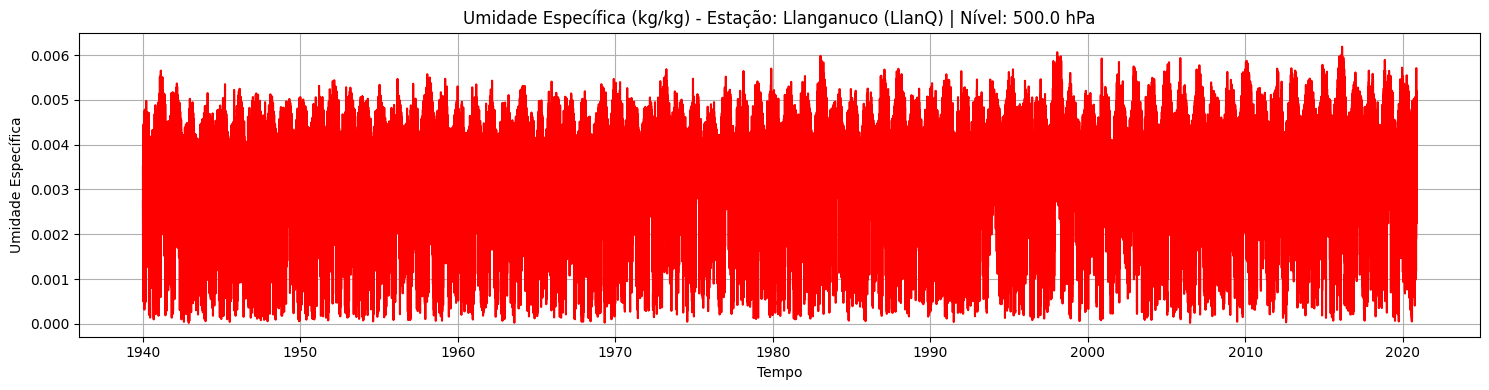

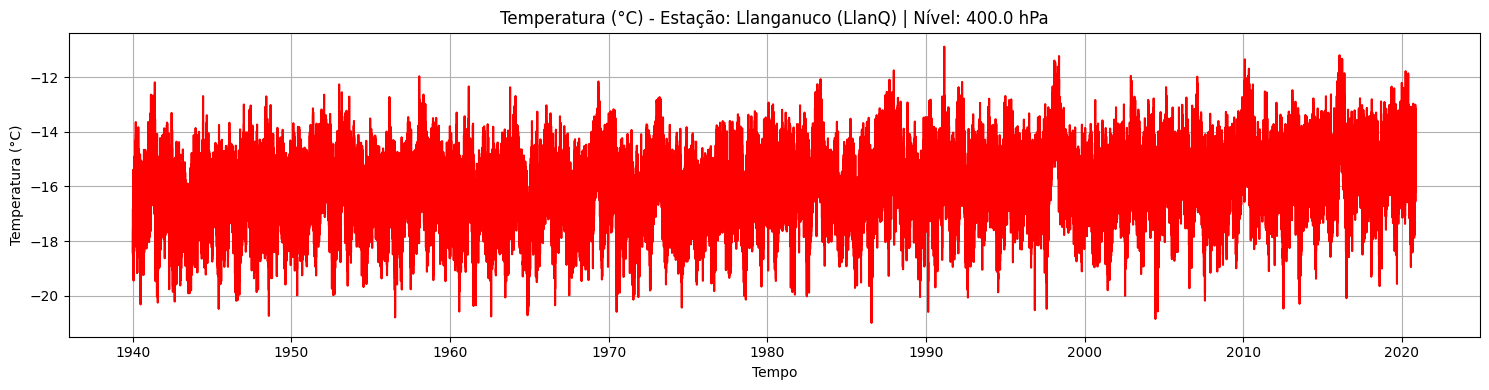

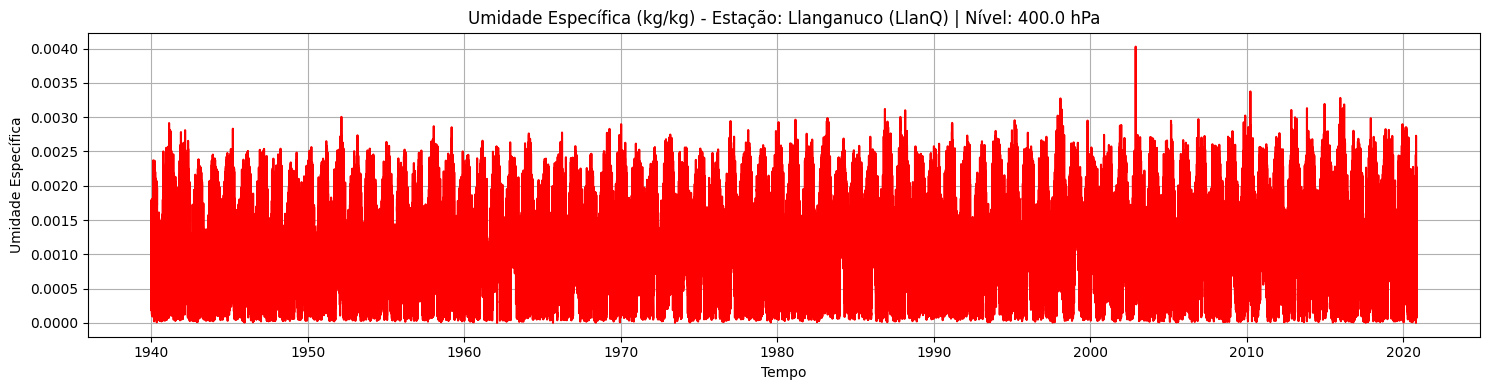

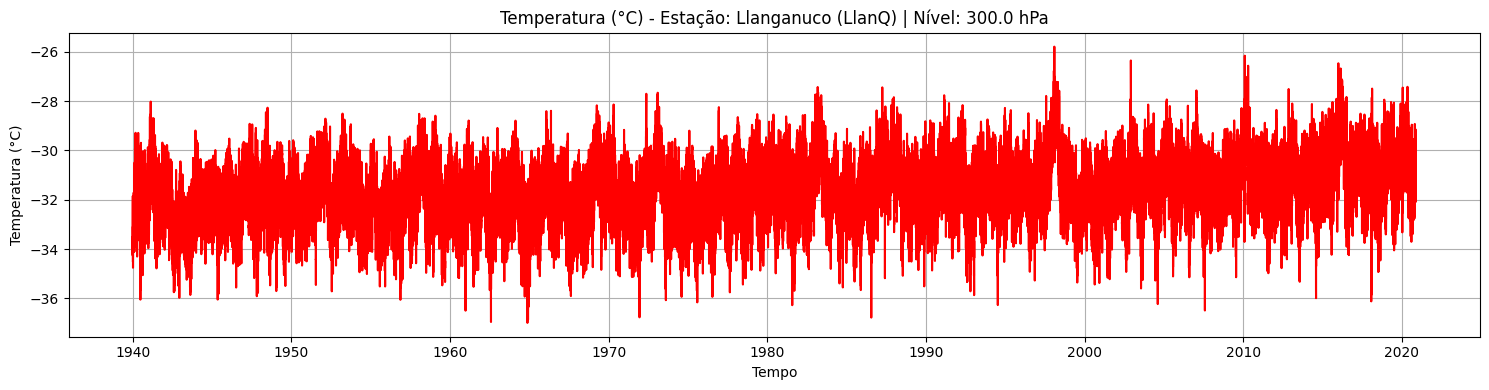

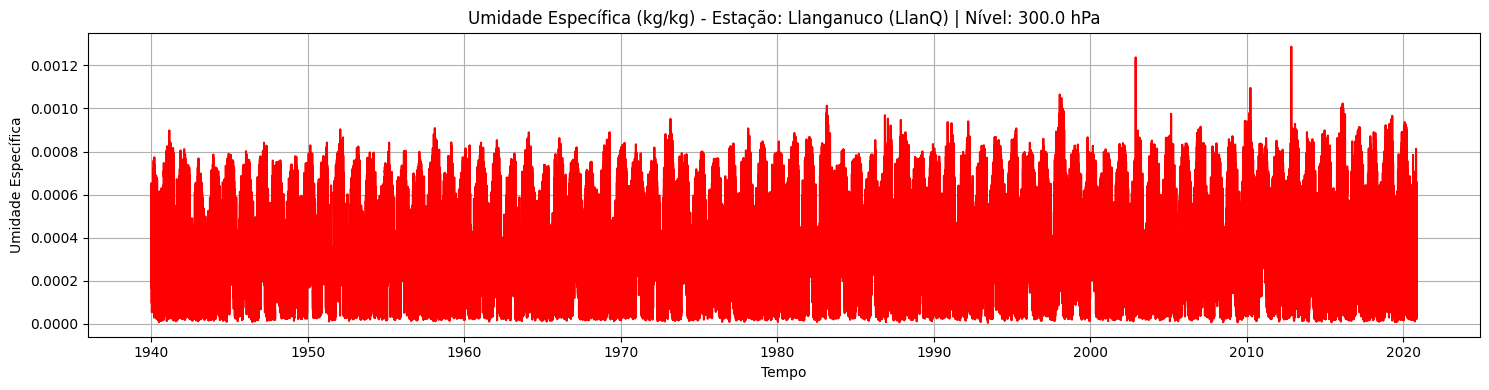

In [9]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

# Caminho dos arquivos .nc
data_dir = "/home/lacrio2/Documentos/LACRIO/PROJETO/LACRIO/Analises/ERA5_dados/dados_era5"
nc_files = sorted([f for f in os.listdir(data_dir) if f.endswith(".nc")])

# Estações
stations = [
    {"name": "CDAWX", "lat": -9.46 , "lon": -77.37, "color": "green"},
    {"name": "Cuchillacocha – CuchQ", "lat": -9.41, "lon": -77.35, "color": "blue"},
    {"name": "Llanganuco (LlanQ)", "lat": -9.07, "lon": -77.65, "color": "red"}
]

# Inicializa dicionários de DataFrames: {(station, level): pd.Series()}
temperature_df = {}
humidity_df = {}

# Descobrir níveis de pressão no primeiro arquivo
sample_file = xr.open_dataset(os.path.join(data_dir, nc_files[0]))
pressure_levels = sample_file.pressure_level.values
sample_file.close()

# Inicializa estruturas
for s in stations:
    for level in pressure_levels:
        key = (s["name"], level)
        temperature_df[key] = pd.Series(dtype=float)
        humidity_df[key] = pd.Series(dtype=float)

# Função para extrair variável
def extract_series(ds, var, lat, lon, level):
    return ds[var].sel(pressure_level=level, latitude=lat, longitude=lon, method="nearest").to_series()

# Processa arquivos
for file in nc_files:
    path = os.path.join(data_dir, file)
    ds = xr.open_dataset(path)

    for s in stations:
        lat, lon, name = s["lat"], s["lon"], s["name"]
        
        for level in pressure_levels:
            key = (name, level)
            try:
                temp = extract_series(ds, "t", lat, lon, level)
                q = extract_series(ds, "q", lat, lon, level)

                temperature_df[key] = pd.concat([temperature_df[key], temp])
                humidity_df[key] = pd.concat([humidity_df[key], q])
            except Exception as e:
                print(f"Erro ao extrair {name} nível {level}: {e}")

    ds.close()

# Converter dicionários para DataFrames indexados por tempo
df_temp = pd.DataFrame({k: v for k, v in temperature_df.items()})
df_q = pd.DataFrame({k: v for k, v in humidity_df.items()})

df_temp.index = pd.to_datetime(df_temp.index)
df_q.index = pd.to_datetime(df_q.index)
df_temp.sort_index(inplace=True)
df_q.sort_index(inplace=True)

# Converte temperatura para Celsius
df_temp_celsius = df_temp - 273.15

# --- Geração de gráficos separados por estação e nível ---
for s in stations:
    name = s["name"]
    color = s["color"]
    
    for level in pressure_levels:
        key = (name, level)
        
        # Temperatura
        plt.figure(figsize=(15, 4))
        plt.plot(df_temp_celsius[key], color=color)
        plt.title(f"Temperatura (°C) - Estação: {name} | Nível: {level} hPa")
        plt.ylabel("Temperatura (°C)")
        plt.xlabel("Tempo")
        plt.grid()
        plt.tight_layout()
        plt.show()
        
        # Umidade específica
        plt.figure(figsize=(15, 4))
        plt.plot(df_q[key], color=color)
        plt.title(f"Umidade Específica (kg/kg) - Estação: {name} | Nível: {level} hPa")
        plt.ylabel("Umidade Específica")
        plt.xlabel("Tempo")
        plt.grid()
        plt.tight_layout()
        plt.show()
